In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
GEFCOM_PATH = Path("/mnt/c/Users/Vikash Rathore/OneDrive/Desktop/Energy Load Predictor/datasets/v1/gefcom.csv")

In [3]:
gefcom_raw = pd.read_csv(GEFCOM_PATH)
print("Available Zones in GEFCom:", gefcom_raw["zone"].unique())

Available Zones in GEFCom: ['CT' 'MASS' 'ME' 'NEMASSBOST' 'NH' 'RI' 'SEMASS' 'TOTAL' 'VT' 'WCMASS']


In [4]:
gefcom_raw.head()

,ts,zone,demand,drybulb,dewpnt,date,year,month,hour,day_of_week,day_of_year,weekend,holiday_name,holiday,trend
0,1.046477e+09,CT,3386.0,25.0,19.0,12112.0,2003.0,Mar,1.0,Sat,60.0,True,NaN,False,0.0
1,1.046480e+09,CT,3258.0,23.0,18.0,12112.0,2003.0,Mar,2.0,Sat,60.0,True,NaN,False,1.0
2,1.046484e+09,CT,3189.0,22.0,18.0,12112.0,2003.0,Mar,3.0,Sat,60.0,True,NaN,False,2.0
3,1.046488e+09,CT,3157.0,22.0,19.0,12112.0,2003.0,Mar,4.0,Sat,60.0,True,NaN,False,3.0
4,1.046491e+09,CT,3166.0,23.0,19.0,12112.0,2003.0,Mar,5.0,Sat,60.0,True,NaN,False,4.0


In [7]:
#Isolate Connecticut (CT) zone data
ct_raw = gefcom_raw[gefcom_raw["zone"] == "CT"].copy()

In [8]:
ct_raw["timestamp"] = pd.to_datetime(ct_raw["ts"], unit="s")
ct = ct_raw.set_index("timestamp").sort_index()

In [9]:
ct = ct[["demand", "drybulb", "dewpnt"]].rename(columns={"demand": "load", "dewpnt": "dewpoint"})

print(f"CT Zone Shape: {ct.shape}")
print(f"Date Range: {ct.index.min()} to {ct.index.max()}")
print(f"Missing Values:\n{ct.isnull().sum()}")

CT Zone Shape: (124171, 3)
Date Range: 2003-03-01 00:00:00 to 2017-04-30 23:00:00
Missing Values:
load        0
drybulb     0
dewpoint    0
dtype: int64


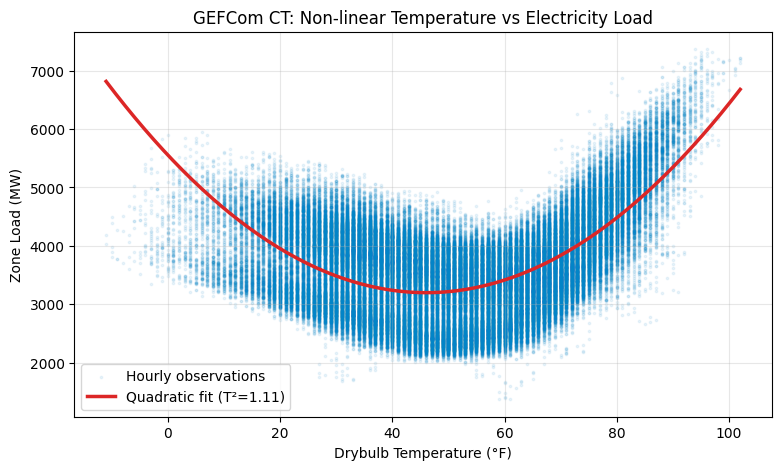

In [18]:
plt.figure(figsize=(9, 5))
plt.scatter(ct["drybulb"], ct["load"], alpha=0.08, color="#0284c7", s=3, label="Hourly observations")
poly_coefs = np.polyfit(ct["drybulb"].dropna(), ct["load"].dropna(), deg=2)
t_range = np.linspace(ct["drybulb"].min(), ct["drybulb"].max(), 200)
load_fit = poly_coefs[0] * t_range**2 + poly_coefs[1] * t_range + poly_coefs[2]

plt.plot(t_range, load_fit, color="#dc2626", linewidth=2.5, label=f"Quadratic fit (T²={poly_coefs[0]:.2f})")
plt.title("GEFCom CT: Non-linear Temperature vs Electricity Load", fontsize=12)
plt.xlabel("Drybulb Temperature (°F)")
plt.ylabel("Zone Load (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
train_gefcom = ct.loc["2012-01-01 00:00:00":"2014-12-31 23:00:00"]
val_gefcom = ct.loc["2015-01-01 00:00:00":"2015-12-31 23:00:00"]
test_gefcom = ct.loc["2016-01-01 00:00:00":"2016-12-31 23:00:00"]

print(f"GEFCom Train (2012-2014): {len(train_gefcom)} hours ({train_gefcom.index.min()} to {train_gefcom.index.max()})")
print(f"GEFCom Val (2015): {len(val_gefcom)} hours ({val_gefcom.index.min()} to {val_gefcom.index.max()})")
print(f"GEFCom Test (2016): {len(test_gefcom)} hours ({test_gefcom.index.min()} to {test_gefcom.index.max()})")

GEFCom Train (2012–2014): 26298 hours (2012-01-01 00:00:00 to 2014-12-31 23:00:00)
GEFCom Val (2015): 8758 hours (2015-01-01 00:00:00 to 2015-12-31 23:00:00)
GEFCom Test (2016): 8782 hours (2016-01-01 00:00:00 to 2016-12-31 23:00:00)


In [21]:
assert train_gefcom.index.max() < val_gefcom.index.min()
assert val_gefcom.index.max() < test_gefcom.index.min()
print("GEFCom split temporal integrity confirmed.")

GEFCom split temporal integrity confirmed.


In [22]:
OUT_DIR = Path("/mnt/c/Users/Vikash Rathore/OneDrive/Desktop/Energy Load Predictor/data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [23]:
ct.to_parquet(OUT_DIR / "gefcom_ct_clean.parquet")

In [24]:
train_gefcom.index.to_series().to_frame("timestamp").to_parquet(OUT_DIR / "gefcom_train_idx.parquet")
val_gefcom.index.to_series().to_frame("timestamp").to_parquet(OUT_DIR / "gefcom_val_idx.parquet")
test_gefcom.index.to_series().to_frame("timestamp").to_parquet(OUT_DIR / "gefcom_test_idx.parquet")

print(f"Successfully generated GEFCom CT Parquet files in: {OUT_DIR}")

Successfully generated GEFCom CT Parquet files in: /mnt/c/Users/Vikash Rathore/OneDrive/Desktop/Energy Load Predictor/data/processed
